In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

In [3]:
df.head(5)

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [5]:
df.isnull().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

In [17]:
df["profession"].value_counts()

profession
student          644
farmer           639
driver           631
doctor           630
artist           626
engineer         616
teacher          612
office_worker    602
Name: count, dtype: int64

In [15]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [21]:
df.select_dtypes('object').columns.tolist

<bound method IndexOpsMixin.tolist of Index(['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married',
       'profession', 'health_risk'],
      dtype='object')>

In [23]:
from sklearn.preprocessing import LabelEncoder
la=LabelEncoder()
for i in ['exercise', 'sugar_intake', 'smoking', 'alcohol', 'married',
       'profession', 'health_risk']:
    df[i]=la.fit_transform(df[i])

In [24]:
df

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,1,6.1,2,1,1,1,5,17.6,0
1,69,76,170,0,6.9,0,0,0,0,7,26.3,0
2,46,106,153,0,6.6,1,1,0,0,0,45.3,0
3,32,54,186,2,8.5,2,0,0,0,0,15.6,1
4,60,98,195,0,8.0,1,0,0,1,7,25.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,2,7.2,1,0,0,1,2,21.4,1
4996,39,86,183,1,7.4,1,0,0,1,3,25.7,0
4997,48,56,194,3,7.2,0,1,1,1,3,14.9,0
4998,34,109,148,2,9.9,2,0,0,1,1,49.8,1


In [25]:
#eda
df.describe()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000
mean,48.805600,77.359200,171.933200,1.494200,6.997060,1.301200,0.195400,0.25180,0.603600,3.490800,26.84388,0.302000
std,17.906991,18.714567,15.822225,0.973322,1.432849,0.782688,0.396548,0.43409,0.489198,2.290014,8.25249,0.459171
min,18.000000,45.000000,145.000000,0.000000,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,11.40000,0.000000
25%,34.000000,61.000000,158.000000,1.000000,6.000000,1.000000,0.000000,0.00000,0.000000,1.000000,20.30000,0.000000
50%,49.000000,77.000000,171.500000,2.000000,7.000000,2.000000,0.000000,0.00000,1.000000,3.000000,26.00000,0.000000
75%,64.000000,94.000000,186.000000,2.000000,8.000000,2.000000,0.000000,1.00000,1.000000,6.000000,32.40000,1.000000
max,79.000000,109.000000,199.000000,3.000000,10.000000,2.000000,1.000000,1.00000,1.000000,7.000000,51.40000,1.000000


In [28]:
df.median()

age              49.0
weight           77.0
height          171.5
exercise          2.0
sleep             7.0
sugar_intake      2.0
smoking           0.0
alcohol           0.0
married           1.0
profession        3.0
bmi              26.0
health_risk       0.0
dtype: float64

In [29]:
df.corr()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
age,1.000000,0.010220,0.020501,0.000612,-0.022504,0.014940,0.011435,0.019320,0.004903,0.001581,-0.011407,-0.379783
weight,0.010220,1.000000,0.001637,0.007286,-0.012756,0.013220,0.004773,-0.006014,-0.012390,0.000539,0.784869,-0.328684
height,0.020501,0.001637,1.000000,-0.023056,-0.016776,-0.012913,0.010976,0.012614,0.013765,-0.009320,-0.596046,0.178419
exercise,0.000612,0.007286,-0.023056,1.000000,-0.002400,-0.016350,0.007861,-0.003881,-0.000628,-0.041981,0.018284,-0.043077
sleep,-0.022504,-0.012756,-0.016776,-0.002400,1.000000,0.018770,0.011362,0.006111,-0.021583,0.004025,-0.001544,0.138019
sugar_intake,0.014940,0.013220,-0.012913,-0.016350,0.018770,1.000000,0.004981,-0.007189,-0.018297,-0.026467,0.018449,0.133692
smoking,0.011435,0.004773,0.010976,0.007861,0.011362,0.004981,1.000000,0.003476,0.000292,-0.000994,-0.002572,-0.252741
alcohol,0.019320,-0.006014,0.012614,-0.003881,0.006111,-0.007189,0.003476,1.000000,-0.017834,-0.001996,-0.010422,-0.180867
married,0.004903,-0.012390,0.013765,-0.000628,-0.021583,-0.018297,0.000292,-0.017834,1.000000,0.008529,-0.018142,0.019204
profession,0.001581,0.000539,-0.009320,-0.041981,0.004025,-0.026467,-0.000994,-0.001996,0.008529,1.000000,0.004082,-0.013528


In [30]:
#variance
df.var()

age             320.660341
weight          350.235022
height          250.342806
exercise          0.947356
sleep             2.053056
sugar_intake      0.612601
smoking           0.157250
alcohol           0.188434
married           0.239315
profession        5.244164
bmi              68.103587
health_risk       0.210838
dtype: float64

In [31]:
#std
df.std()

age             17.906991
weight          18.714567
height          15.822225
exercise         0.973322
sleep            1.432849
sugar_intake     0.782688
smoking          0.396548
alcohol          0.434090
married          0.489198
profession       2.290014
bmi              8.252490
health_risk      0.459171
dtype: float64

In [32]:
df.skew()

age            -0.013819
weight         -0.006038
height          0.022961
exercise       -0.151020
sleep          -0.062122
sugar_intake   -0.583405
smoking         1.536873
alcohol         1.143998
married        -0.423720
profession      0.004117
bmi             0.474380
health_risk     0.862769
dtype: float64

In [48]:
plot=df.var()
plot1=df.skew()
plot3=df.std()
plot=pd.DataFrame({"var":plot,"skew":plot1,"std":plot3})
plot


,var,skew,std
age,320.660341,-0.013819,17.906991
weight,350.235022,-0.006038,18.714567
height,250.342806,0.022961,15.822225
exercise,0.947356,-0.151020,0.973322
sleep,2.053056,-0.062122,1.432849
sugar_intake,0.612601,-0.583405,0.782688
smoking,0.157250,1.536873,0.396548
alcohol,0.188434,1.143998,0.434090
married,0.239315,-0.423720,0.489198
profession,5.244164,0.004117,2.290014


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns 

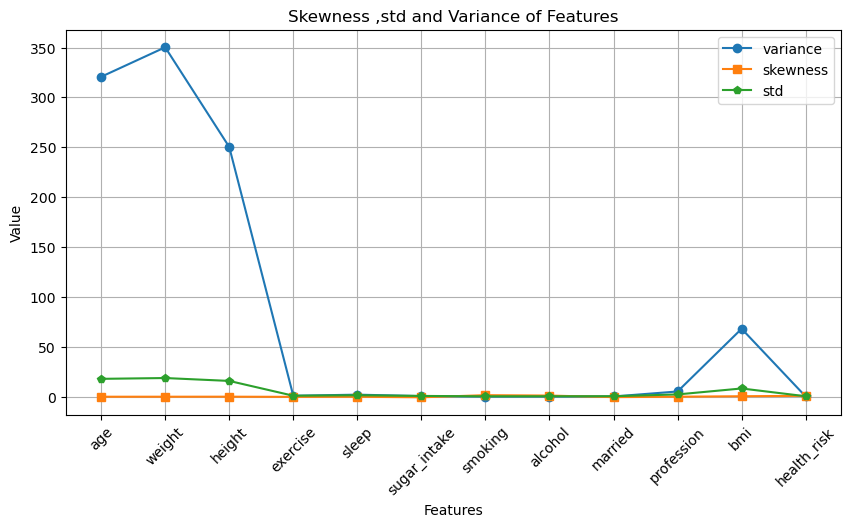

In [49]:
plt.figure(figsize=(10,5))
plt.plot(plot.index,plot["var"], marker='o', label="variance")
plt.plot(plot.index,plot["skew"], marker='s', label="skewness")
plt.plot(plot.index,plot["std"], marker='p', label="std")
plt.title("Skewness ,std and Variance of Features")
plt.xlabel("Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


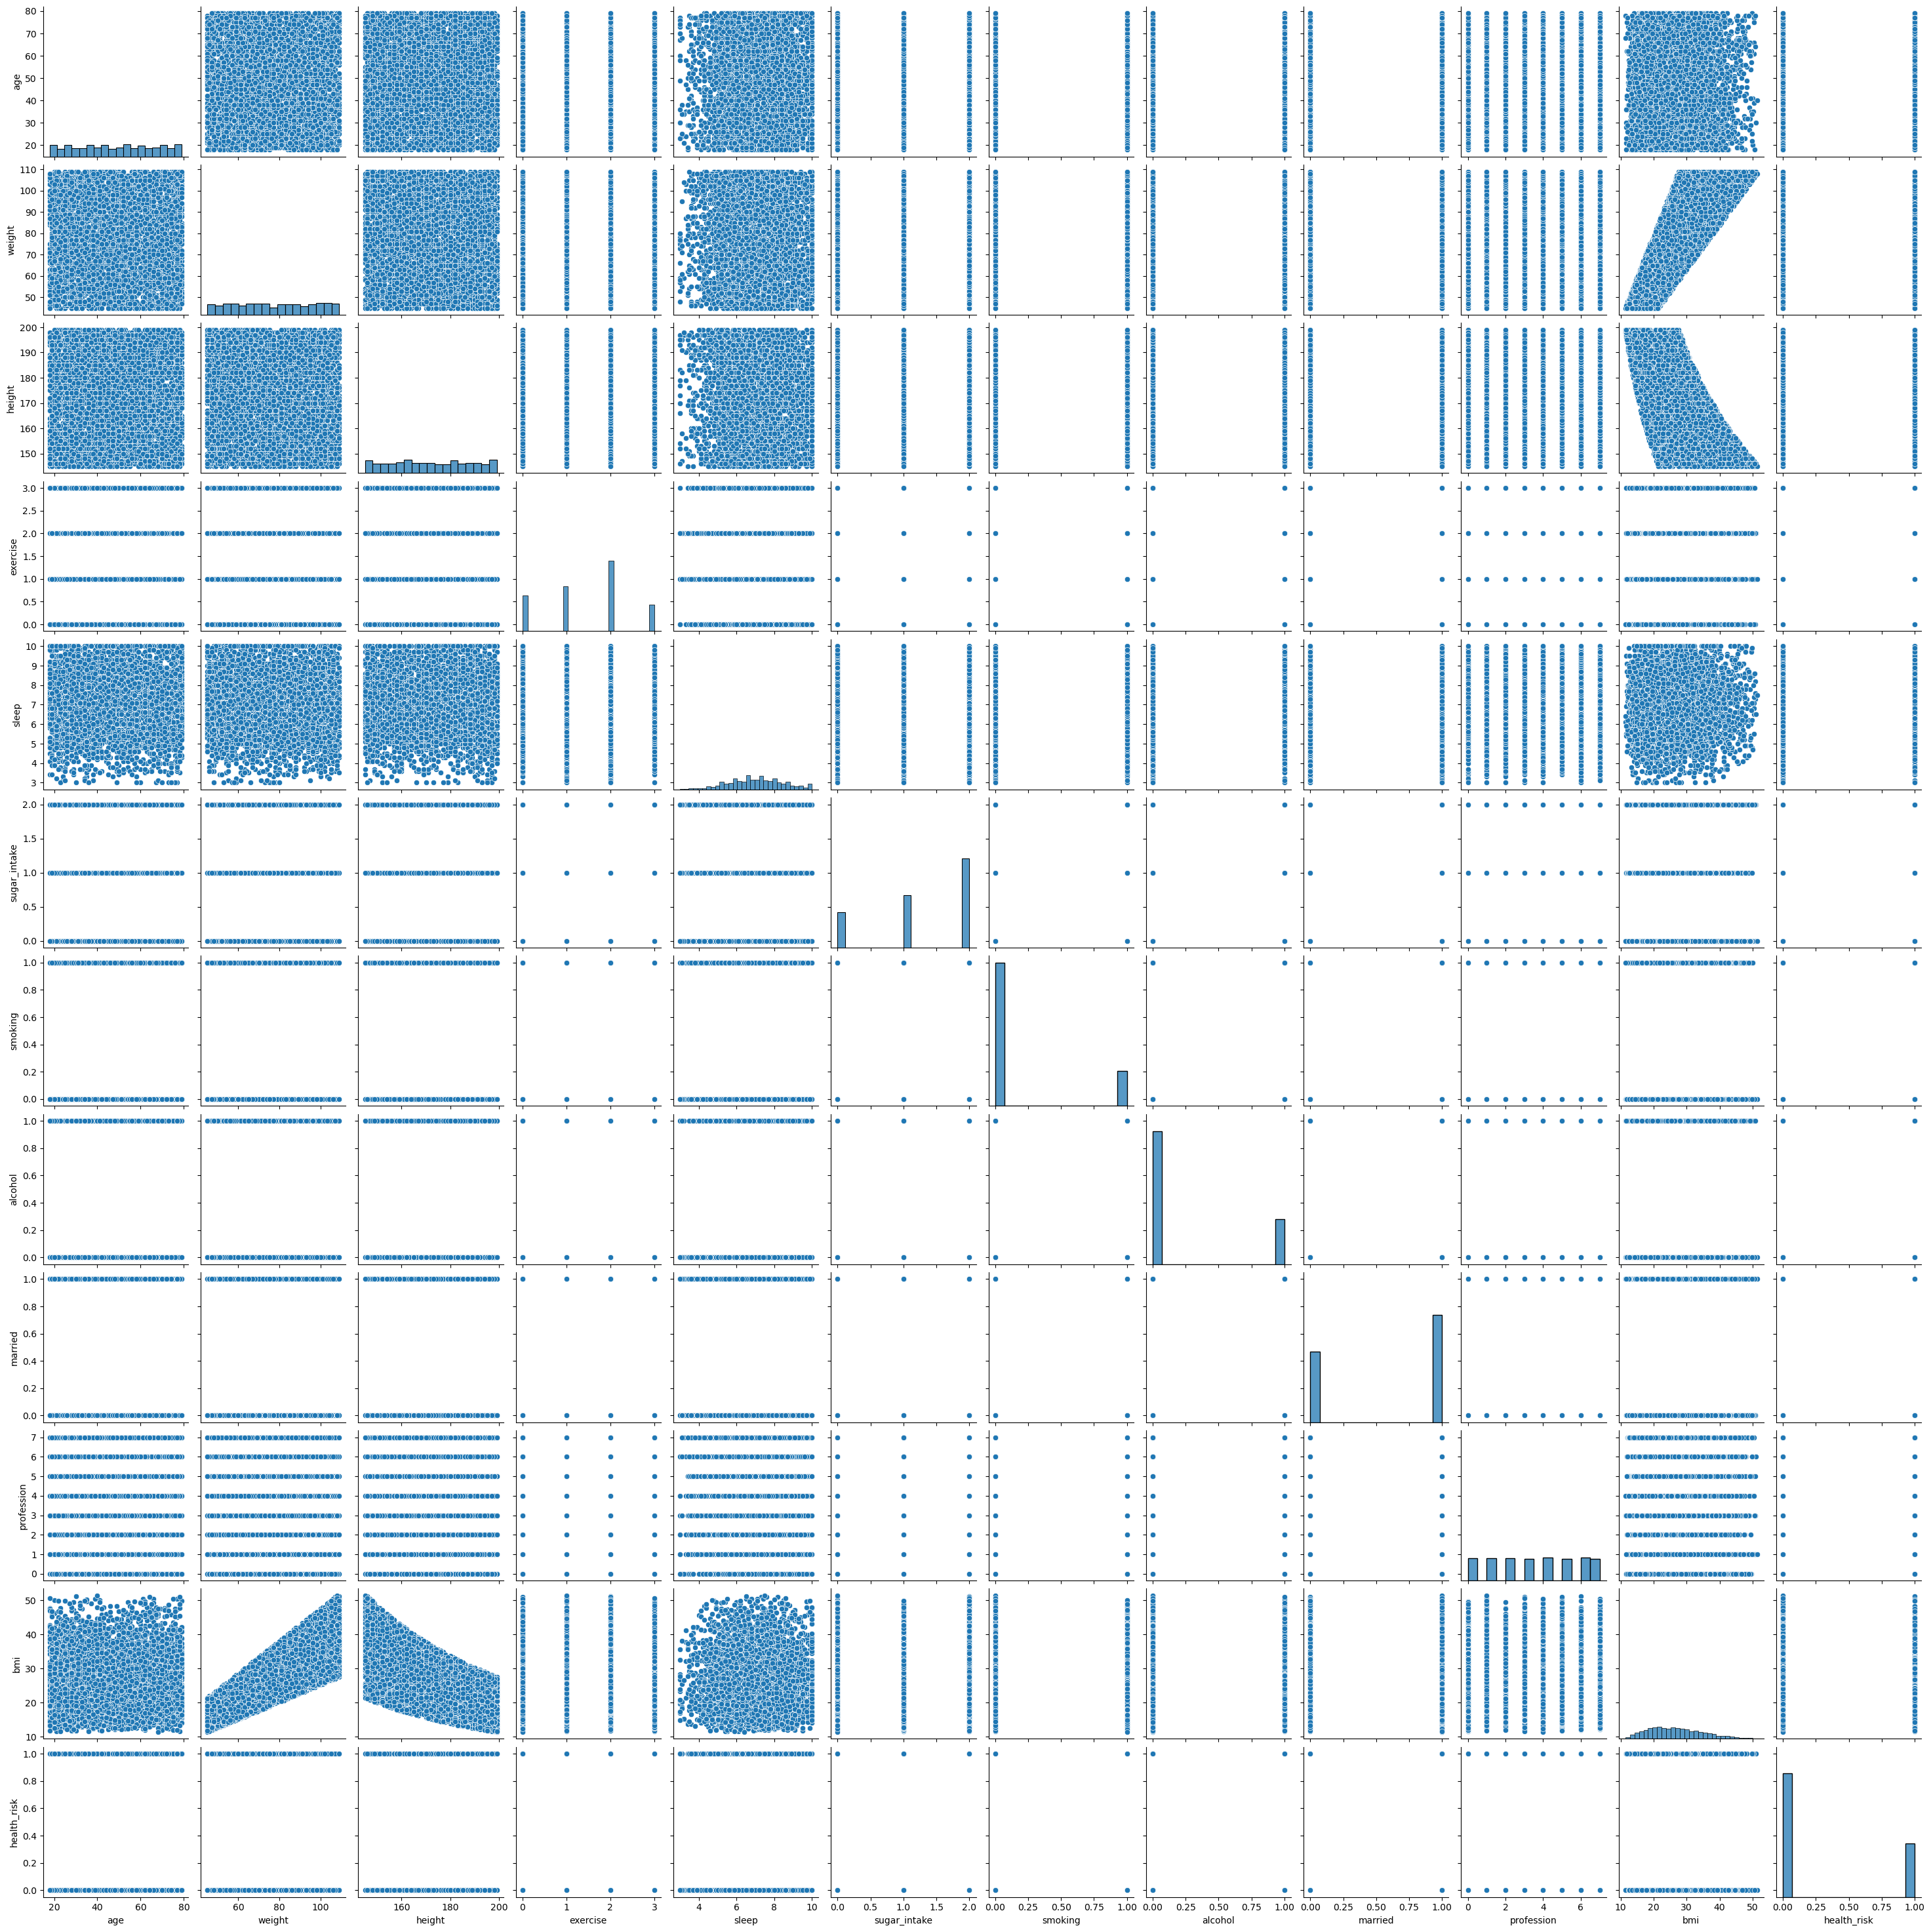

In [51]:
sns.pairplot(df)
plt.show()

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [68]:
st=StandardScaler()
df_s=st.fit_transform(y)

In [69]:
df_s.shape

(5000, 11)

In [70]:
df_s

array([[ 0.40180505, -0.55359208,  1.45801914, ...,  0.81038652,
         0.65910118, -1.12024429],
       [ 1.12785109, -0.07263518, -0.12219478, ..., -1.23397907,
         1.53254563, -0.06591155],
       [-0.15669191,  1.53055448, -1.19674025, ..., -1.23397907,
        -1.52450994,  2.2366542 ],
       ...,
       [-0.04499251, -1.14142828,  1.39481058, ...,  0.81038652,
        -0.21434327, -1.447451  ],
       [-0.82688825,  1.69087344, -1.51278304, ...,  0.81038652,
        -1.08778772,  2.78199872],
       [ 1.29540018, -1.62238518, -1.44957448, ...,  0.81038652,
        -0.65106549, -0.68396867]], shape=(5000, 11))

In [67]:
x=df["health_risk"]
y=df.drop("health_risk",axis=1)
y

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi
0,56,67,195,1,6.1,2,1,1,1,5,17.6
1,69,76,170,0,6.9,0,0,0,0,7,26.3
2,46,106,153,0,6.6,1,1,0,0,0,45.3
3,32,54,186,2,8.5,2,0,0,0,0,15.6
4,60,98,195,0,8.0,1,0,0,1,7,25.8
...,...,...,...,...,...,...,...,...,...,...,...
4995,42,75,187,2,7.2,1,0,0,1,2,21.4
4996,39,86,183,1,7.4,1,0,0,1,3,25.7
4997,48,56,194,3,7.2,0,1,1,1,3,14.9
4998,34,109,148,2,9.9,2,0,0,1,1,49.8


In [90]:
x_train,x_test,y_train,y_test=train_test_split(y,x,test_size=0.2,random_state=42)
y_train

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi
4227,55,106,191,3,9.3,2,0,1,0,7,29.1
4676,47,75,153,2,10.0,0,0,1,0,5,32.0
800,29,89,173,1,6.3,1,0,0,0,7,29.7
3671,49,88,154,1,7.5,2,0,1,0,1,37.1
4193,39,68,190,3,7.4,1,0,1,1,6,18.8
...,...,...,...,...,...,...,...,...,...,...,...
4426,44,56,167,2,10.0,2,0,0,0,0,20.1
466,23,54,157,1,4.8,2,0,0,1,4,21.9
3092,21,59,184,0,4.2,1,0,1,0,2,17.4
3772,55,77,180,2,4.8,1,0,0,1,4,23.8


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [86]:
la=LogisticRegression()
la.fit(x_train,y_train)

C:\Users\AASTIK\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [87]:
xg=XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

In [88]:
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [98]:
y_test

1501    0
2586    1
2653    1
1055    0
705     0
       ..
4711    0
2313    0
3214    0
2732    0
1926    0
Name: health_risk, Length: 1000, dtype: int64

In [91]:
pre=la.predict(x_test)

np.int64(1)

In [95]:
y_pred = (pre > 0.5).astype(int)

# Now import metrics and evaluate
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       708
           1       0.76      0.69      0.72       292

    accuracy                           0.85      1000
   macro avg       0.82      0.80      0.81      1000
weighted avg       0.84      0.85      0.84      1000



In [105]:
import pickle

with open("model.pkl", "rb") as f:
    model = pickle.load(f)

prediction = model.predict(x_test)

EOFError: Ran out of input